In [17]:
import pandas as pd
import os

# 出力用のリスト
all_data = []

# 被験者IDは1〜19
for i in range(1, 20):
    # ファイル名を生成
    subject_id = f"{i:03}"  # 001, 002, ...
    file_path = f"./exported_csv/fixation_sliced_by_time/fixation_{subject_id}-003-0_interval_0.0-5.0s.csv"
    
    # ファイルがなければスキップ
    if not os.path.exists(file_path):
        print(f"{file_path} は存在しません。スキップします。")
        continue
    
    # 読み込み
    df = pd.read_csv(file_path)
    
    # データが空の場合は「0」を1行だけ作る
    if df.empty:
        print(f"{file_path} はデータが空です。0を記録します。")
        df = pd.DataFrame({"empty": [0]})
    
    # 被験者IDを先頭列に追加
    df.insert(0, "subject_id", subject_id)
    
    all_data.append(df)

# すべて結合
merged_df = pd.concat(all_data, ignore_index=True)

# 出力
merged_df.to_csv("merged_champion_fixations_image3-1.csv", index=False, encoding="utf-8-sig")

print("✅ 統合ファイル 'merged_champion_fixations.csv' を作成しました。")


./exported_csv/fixation_sliced_by_time/fixation_003-003-0_interval_0.0-5.0s.csv は存在しません。スキップします。
./exported_csv/fixation_sliced_by_time/fixation_006-003-0_interval_0.0-5.0s.csv は存在しません。スキップします。
./exported_csv/fixation_sliced_by_time/fixation_007-003-0_interval_0.0-5.0s.csv は存在しません。スキップします。
./exported_csv/fixation_sliced_by_time/fixation_008-003-0_interval_0.0-5.0s.csv は存在しません。スキップします。
./exported_csv/fixation_sliced_by_time/fixation_010-003-0_interval_0.0-5.0s.csv は存在しません。スキップします。
./exported_csv/fixation_sliced_by_time/fixation_014-003-0_interval_0.0-5.0s.csv は存在しません。スキップします。
✅ 統合ファイル 'merged_champion_fixations.csv' を作成しました。


In [18]:
import pandas as pd

# 処理対象ファイルと対応する画像名
file_paths = {
    "image2_6": "merged_champion_fixations_image2_6.csv",
    "image1_7": "merged_champion_fixations_image1_7.csv",
    "image3_1": "merged_champion_fixations_image3-1.csv"
}

# 結果を格納するリスト
summary_list = []

for image_label, path in file_paths.items():
    # データを読み込み
    df = pd.read_csv(path)
    
    # データがない場合スキップ
    if df.empty:
        print(f"{image_label}: データがありません。スキップします。")
        continue

    # 被験者IDでグループ化
    grouped = df.groupby("subject_id")

    # 被験者ごとの集計
    for subject_id, group in grouped:
        # 総注視回数
        total_fixations = len(group)
        # 総注視時間
        total_duration = group["duration_ms"].sum()

        # AOIごとの件数
        aoi_counts = group["AOI_label"].value_counts().to_dict()

        # データを整形
        summary = {
            "image": image_label,
            "subject_id": subject_id,
            "total_fixations": total_fixations,
            "total_duration": total_duration,
        }

        # AOIを全部列に出す（存在しない場合は0）
        for aoi in ["left_eye", "right_eye", "nose", "mouth", "outside"]:
            summary[f"{aoi}_count"] = aoi_counts.get(aoi, 0)

        summary_list.append(summary)

# すべての結果をDataFrame化
summary_df = pd.DataFrame(summary_list)

# CSVに保存
summary_df.to_csv("champion_summary_by_subject.csv", index=False)

print("集計が完了しました。ファイル: champion_summary_by_subject.csv")


PermissionError: [Errno 13] Permission denied: 'champion_summary_by_subject.csv'

In [29]:
import pandas as pd

filepath = "merged_champion_fixations_image1_7.csv"

df = pd.read_csv(filepath)
print("列名:", df.columns)
print(df.head())



列名: Index(['subject_id', 'start_time', 'end_time', 'duration_ms', 'x_mean_deg',
       'y_mean_deg', 'trial', 'x_px', 'y_px', 'x_norm', 'y_norm', 'AOI_label',
       'relative_start_sec'],
      dtype='object')
   subject_id    start_time      end_time  duration_ms  x_mean_deg  \
0           1  1.732521e+09  1.732521e+09   909.999847   -0.366395   
1           1  1.732521e+09  1.732521e+09   397.000074    0.238575   
2           1  1.732521e+09  1.732521e+09   167.000055   -0.767218   
3           1  1.732521e+09  1.732521e+09   206.000090   -0.445849   
4           1  1.732521e+09  1.732521e+09   144.000053    2.415615   

   y_mean_deg  trial         x_px        y_px    x_norm    y_norm  AOI_label  \
0    0.671698    6.0   944.523283  568.347301  0.491939  0.526248  right_eye   
1    0.512740    6.0   970.077448  561.638459  0.505249  0.520036  right_eye   
2    0.283169    6.0   927.590862  551.949978  0.483120  0.511065    outside   
3    0.374731    6.0   941.167006  555.814045  0

In [3]:
import pandas as pd

files = {
    "image1_7": "merged_champion_fixations_image1_7.csv",
    "image2_6": "merged_champion_fixations_image2_6.csv",
    "image3_1": "merged_champion_fixations_image3-1.csv"
}

for label, filepath in files.items():
    df = pd.read_csv(filepath)
    print(f"=== {label} ===")
    print("列名:", df.columns.tolist())
    print("欠損値の合計:")
    print(df[["x_px", "y_px"]].isnull().sum())
    print("x_px dtype:", df["x_px"].dtype)
    print("y_px dtype:", df["y_px"].dtype)
    print("先頭5行:")
    print(df[["x_px", "y_px"]].head())
    print()


=== image1_7 ===
列名: ['subject_id', 'start_time', 'end_time', 'duration_ms', 'x_mean_deg', 'y_mean_deg', 'trial', 'x_px', 'y_px', 'x_norm', 'y_norm', 'AOI_label', 'relative_start_sec']
欠損値の合計:
x_px    0
y_px    0
dtype: int64
x_px dtype: float64
y_px dtype: float64
先頭5行:
          x_px        y_px
0   944.523283  568.347301
1   970.077448  561.638459
2   927.590862  551.949978
3   941.167006  555.814045
4  1062.095853  561.893661

=== image2_6 ===
列名: ['subject_id', 'start_time', 'end_time', 'duration_ms', 'x_mean_deg', 'y_mean_deg', 'trial', 'x_px', 'y_px', 'x_norm', 'y_norm', 'AOI_label', 'relative_start_sec', 'x_mean_norm_corrected', 'y_mean_norm_corrected', 'x_px_raw', 'y_px_raw']
欠損値の合計:
x_px    0
y_px    0
dtype: int64
x_px dtype: float64
y_px dtype: float64
先頭5行:
          x_px        y_px
0   969.087783  633.709767
1   955.669659  640.398039
2   938.567877  663.604524
3   976.267574  574.499979
4  1120.099531  665.361195

=== image3_1 ===
列名: ['subject_id', 'start_time', 'end_t

image1_7: ヒートマップを保存しました -> heatmap_image1_7_normalized.png
image2_6: ヒートマップを保存しました -> heatmap_image2_6_normalized.png
image3_1: ヒートマップを保存しました -> heatmap_image3_1_normalized.png
すべてのヒートマップが完了しました。


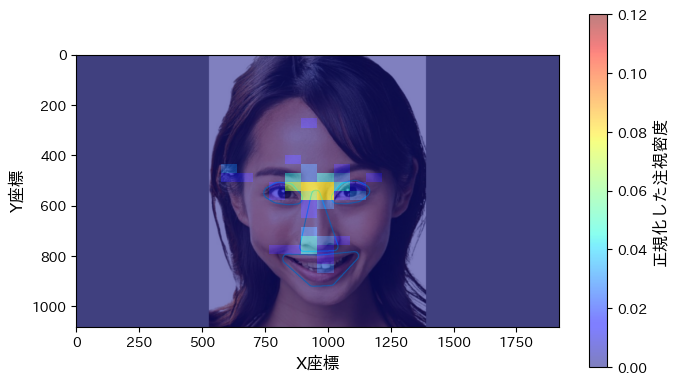

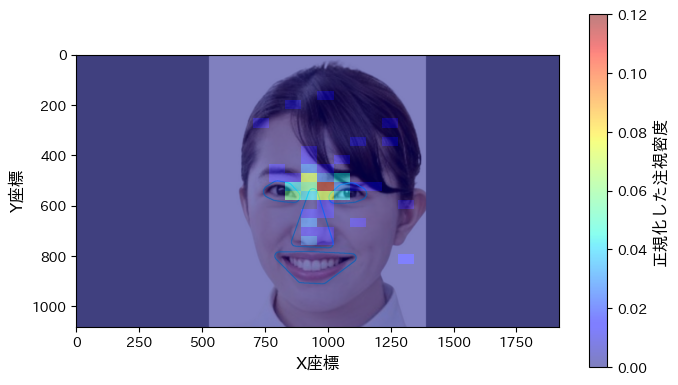

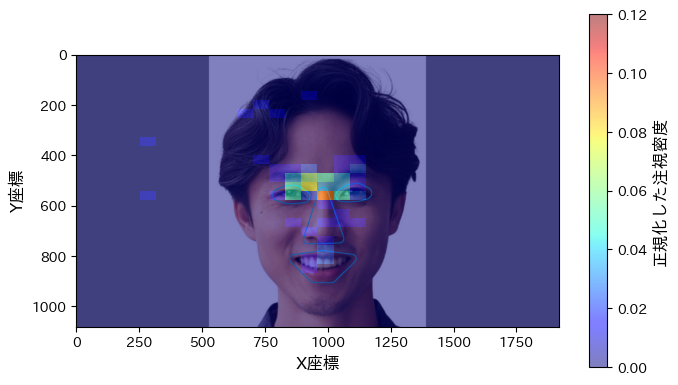

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import japanize_matplotlib

# ファイルとラベル
files = {
    "image1_7": "merged_champion_fixations_image1_7.csv",
    "image2_6": "merged_champion_fixations_image2_6.csv",
    "image3_1": "merged_champion_fixations_image3-1.csv"
}

# 背景画像
background_images = {
    "image1_7": "../face_aoi_project/output_aoi/1-7.jpg",
    "image2_6": "../face_aoi_project/output_aoi/2-6.jpg",
    "image3_1": "../face_aoi_project/output_aoi/3-1.jpg"
}

# 画面解像度
screen_width = 1920
screen_height = 1080

# 被験者数（それぞれ正しい人数に置き換えてください）
subject_counts = {
    "image1_7": 9,
    "image2_6": 10,
    "image3_1": 13
}

# 各ファイルを処理
for label, filepath in files.items():
    df = pd.read_csv(filepath)

    if df.empty:
        print(f"{label}: データがありません。")
        continue

    df_clean = df.dropna(subset=["x_px", "y_px"])
    if df_clean.empty:
        print(f"{label}: 欠損除去後データが空です。")
        continue

    x = df_clean["x_px"]
    y = df_clean["y_px"]

    # 2Dヒストグラム（カウント）
    counts, xedges, yedges = np.histogram2d(
        x, y,
        bins=30,
        range=[[0, screen_width], [0, screen_height]]
    )

    # 被験者数で割って正規化
    counts = counts / subject_counts[label]

    # 全体で1にスケーリング
    counts = counts / counts.sum()

    # 背景画像
    img = mpimg.imread(background_images[label])

    fig, ax = plt.subplots(figsize=(7, 4))

    # 背景を表示
    ax.imshow(
        img,
        extent=[0, screen_width, screen_height, 0],  # 上下反転
        aspect='auto'
    )

    # 相対密度をimshow
    cax = ax.imshow(
        counts.T,  # 転置が必要
        extent=[0, screen_width, 0, screen_height],
        origin='lower',
        cmap="jet",
        alpha=0.5,
        vmin=0,
        vmax=0.12
    )

    # カラーバー
    cbar = plt.colorbar(cax, ax=ax)
    cbar.set_label("正規化した注視密度",fontsize=12)

    ax.set_xlim(0, screen_width)
    ax.set_ylim(0, screen_height)
    ax.invert_yaxis()  # 上下をモニタ座標系に合わせる

    ax.set_xlabel("X座標",fontsize=12)
    ax.set_ylabel("Y座標",fontsize=12)
    # ax.set_title(f"注視ヒートマップ（{label} 相対密度）")

    plt.tight_layout()
    outpath = f"heatmap_{label}_normalized.png"
    plt.savefig(outpath, dpi=300)
#     plt.close()

    print(f"{label}: ヒートマップを保存しました -> {outpath}")

print("すべてのヒートマップが完了しました。")
